<a href="https://colab.research.google.com/github/SANGHATI23/sam-brats-robustness-audit/blob/main/01_MedReasoner_Selected_Case_Asset_Recovery_and_Overlay_Build.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — Runtime check
import os, sys, subprocess, platform, shutil, json, re, time, random, hashlib
from pathlib import Path

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        props = torch.cuda.get_device_properties(0)
        print(f"GPU memory: {props.total_memory / 1024**3:.1f} GB")
    else:
        print("WARNING: No GPU. Asset recovery works, but SAM inference will be slow.")
except Exception as e:
    print("Torch check error:", repr(e))

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
GPU memory: 79.3 GB


In [2]:
# CELL 2 — Install dependencies
# Kept explicit so the notebook can run in a fresh Colab runtime.
import subprocess, sys

packages = [
    "nibabel",
    "opencv-python-headless",
    "pandas",
    "numpy",
    "tqdm",
    "pillow",
    "matplotlib",
    "datasets",
    "huggingface_hub",
]

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", *packages],
    check=True
)

# Segment Anything
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "git+https://github.com/facebookresearch/segment-anything.git"],
    check=True
)

print("Dependencies installed.")

Dependencies installed.


In [3]:
# CELL 3 — Imports, seeds, and project configuration
import os, json, re, random, shutil, hashlib, tarfile, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import nibabel as nib
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display

import torch
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from segment_anything import sam_model_registry, SamPredictor

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PIPELINE_VERSION = "medreasoner-asset-build-01-v1"

# Reproduce the EXECUTED brain notebook exactly.
BRAIN_CHANNEL_INDEX = 0
BRAIN_CHANNEL_LABEL = "FLAIR/channel-0 (executed MSD Task01 notebook)"

# The original brain baseline uses a 10-pixel padded oracle GT box.
BRAIN_BOX_PAD = 10

# KiTS23 and MoNuSeg used tight GT boxes (no explicit padding).
KIDNEY_BOX_PAD = 0
HISTO_BOX_PAD = 0

# Automatic source recovery.
AUTO_DOWNLOAD_BRAIN_MSD_IF_MISSING = True
DELETE_BRAIN_TAR_AFTER_EXTRACTION = True

# Reproduction tolerances.
PASS_DICE_ABS_DIFF = 0.002
WARN_DICE_ABS_DIFF = 0.020

print("Pipeline version:", PIPELINE_VERSION)
print("Brain reproduction modality:", BRAIN_CHANNEL_LABEL)

Pipeline version: medreasoner-asset-build-01-v1
Brain reproduction modality: FLAIR/channel-0 (executed MSD Task01 notebook)


In [4]:
# CELL 4 — Mount Google Drive and define permanent output locations
DRIVE_MOUNT = Path("/content/drive")
try:
    from google.colab import drive
    if not (DRIVE_MOUNT / "MyDrive").exists():
        drive.mount(str(DRIVE_MOUNT), force_remount=False)
    else:
        print("Drive already mounted.")
except Exception as e:
    raise RuntimeError(
        "Google Drive is required because Notebook 00 saved the benchmark manifest there."
    ) from e

MYDRIVE = DRIVE_MOUNT / "MyDrive"
PROJECT_ROOT = MYDRIVE / "MedReasoner_SAM_2026"

MANIFEST_DIR = PROJECT_ROOT / "01_manifests"
ASSET_ROOT = PROJECT_ROOT / "02_case_assets"
SOURCE_CACHE = PROJECT_ROOT / "source_cache_metadata"
AUDIT_DIR = PROJECT_ROOT / "00_setup_audit"
LOG_DIR = PROJECT_ROOT / "logs"

for p in [MANIFEST_DIR, ASSET_ROOT, SOURCE_CACHE, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Asset root:", ASSET_ROOT)

Mounted at /content/drive
Project root: /content/drive/MyDrive/MedReasoner_SAM_2026
Asset root: /content/drive/MyDrive/MedReasoner_SAM_2026/02_case_assets


In [5]:
# CELL 5 — Clone/update your SAM repository and load the 220-case manifest
REPO_URL = "https://github.com/SANGHATI23/sam-brats-robustness-audit.git"
REPO_DIR = Path("/content/sam-brats-robustness-audit")

if REPO_DIR.exists() and (REPO_DIR / ".git").exists():
    pull = subprocess.run(
        ["git", "-C", str(REPO_DIR), "pull", "--ff-only"],
        text=True, capture_output=True
    )
    print(pull.stdout[-1000:])
else:
    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)

manifest_candidates = [
    MANIFEST_DIR / "candidate_medreasoner_benchmark.csv",
    MANIFEST_DIR / "candidate_benchmark_with_asset_audit.csv",
]

MANIFEST_PATH = next((p for p in manifest_candidates if p.exists()), None)

if MANIFEST_PATH is None:
    # Last-resort targeted lookup in the project directory.
    hits = list(PROJECT_ROOT.rglob("candidate_medreasoner_benchmark.csv"))
    if hits:
        MANIFEST_PATH = hits[0]

if MANIFEST_PATH is None:
    raise FileNotFoundError(
        "Could not find Notebook 00's candidate benchmark manifest in "
        f"{MANIFEST_DIR}. Run/finish Notebook 00 first."
    )

benchmark = pd.read_csv(MANIFEST_PATH)

required_cols = {
    "benchmark_id", "domain", "record_id", "case_id", "z",
    "dice", "sam_failure_primary", "sam_failure_severe", "sampling_stratum"
}
missing_cols = sorted(required_cols - set(benchmark.columns))
if missing_cols:
    raise ValueError(f"Manifest is missing required columns: {missing_cols}")

# Normalize booleans in case CSV round-trip stored strings.
for c in ["sam_failure_primary", "sam_failure_severe"]:
    if benchmark[c].dtype == object:
        benchmark[c] = benchmark[c].astype(str).str.lower().map({"true": True, "false": False})

print("Manifest:", MANIFEST_PATH)
print("Rows:", len(benchmark))
display(benchmark.groupby(["domain", "sampling_stratum"]).size().reset_index(name="n"))

assert len(benchmark) == 220, (
    f"Expected the fixed Notebook-00 benchmark of 220 rows; found {len(benchmark)}."
)

Manifest: /content/drive/MyDrive/MedReasoner_SAM_2026/01_manifests/candidate_medreasoner_benchmark.csv
Rows: 220


,domain,sampling_stratum,n
0,brain_mri,borderline_0.50-0.74,25
1,brain_mri,failure_0.10-0.49,25
2,brain_mri,severe_<0.10,19
3,brain_mri,strong_>=0.75,25
4,histopathology,borderline_0.50-0.74,11
5,histopathology,failure_0.10-0.49,25
6,kidney_ct,borderline_0.50-0.74,25
7,kidney_ct,failure_0.10-0.49,25
8,kidney_ct,severe_<0.10,15
9,kidney_ct,strong_>=0.75,25


In [6]:
# CELL 6 — General helpers
def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    h = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def safe_name(x):
    x = str(x)
    x = re.sub(r"[^A-Za-z0-9_.-]+", "_", x)
    return x.strip("_")

def find_dir_named(root, name, maxdepth=7, timeout=90):
    root = Path(root)
    if not root.exists():
        return None
    cmd = [
        "find", str(root), "-maxdepth", str(maxdepth),
        "-type", "d", "-name", name, "-print", "-quit"
    ]
    try:
        r = subprocess.run(cmd, text=True, capture_output=True, timeout=timeout)
        out = [x.strip() for x in r.stdout.splitlines() if x.strip()]
        return Path(out[0]) if out else None
    except subprocess.TimeoutExpired:
        print(f"Timed out searching for directory {name!r} under {root}")
        return None

def mask_to_box(mask, pad=0):
    mask = np.asarray(mask) > 0
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    h, w = mask.shape[:2]
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    x0 = max(0, x0 - pad)
    y0 = max(0, y0 - pad)
    x1 = min(w - 1, x1 + pad)
    y1 = min(h - 1, y1 + pad)
    return np.array([x0, y0, x1, y1], dtype=np.float32)

def dice_iou(pred, gt):
    pred = np.asarray(pred) > 0
    gt = np.asarray(gt) > 0
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    dice = (2.0 * inter) / (pred.sum() + gt.sum() + 1e-8)
    iou = inter / (union + 1e-8)
    return float(dice), float(iou)

def ensure_rgb_u8(img):
    img = np.asarray(img)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    if img.shape[-1] == 4:
        img = img[..., :3]
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def save_rgb(path, img_rgb):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), cv2.cvtColor(ensure_rgb_u8(img_rgb), cv2.COLOR_RGB2BGR))

def save_mask(path, mask):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), ((np.asarray(mask) > 0).astype(np.uint8) * 255))

def overlay_fill(img_rgb, mask, color=(255, 0, 0), alpha=0.35):
    out = ensure_rgb_u8(img_rgb).astype(np.float32).copy()
    m = np.asarray(mask) > 0
    c = np.array(color, dtype=np.float32)
    out[m] = (1 - alpha) * out[m] + alpha * c
    return np.clip(out, 0, 255).astype(np.uint8)

def overlay_contours(img_rgb, gt=None, pred=None):
    out = ensure_rgb_u8(img_rgb).copy()

    if gt is not None:
        gt_u8 = ((np.asarray(gt) > 0).astype(np.uint8) * 255)
        contours, _ = cv2.findContours(gt_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        # Internal audit only: GT boundary = green
        cv2.drawContours(out, contours, -1, (0, 255, 0), 2)

    if pred is not None:
        pred_u8 = ((np.asarray(pred) > 0).astype(np.uint8) * 255)
        contours, _ = cv2.findContours(pred_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        # SAM boundary = red in RGB
        cv2.drawContours(out, contours, -1, (255, 0, 0), 2)

    return out

def reproduction_status(abs_diff):
    if pd.isna(abs_diff):
        return "MISSING"
    if abs_diff <= PASS_DICE_ABS_DIFF:
        return "PASS"
    if abs_diff <= WARN_DICE_ABS_DIFF:
        return "WARN"
    return "FAIL"

print("Helpers ready.")

Helpers ready.


In [7]:
# CELL 7 — Recover exact Brain MRI source volumes (MSD Task01 BrainTumour)
brain_df = benchmark[benchmark["domain"] == "brain_mri"].copy()
brain_cases = sorted(brain_df["case_id"].astype(str).unique().tolist())

print("Selected brain rows:", len(brain_df))
print("Unique brain cases:", len(brain_cases))
print("First cases:", brain_cases[:10])

def brain_root_has_case(root, case_id):
    root = Path(root)
    return (
        (root / "imagesTr" / f"{case_id}.nii.gz").exists()
        and (root / "labelsTr" / f"{case_id}.nii.gz").exists()
    )

brain_source_roots = []

# Common current-runtime location.
for p in [
    Path("/content/Task01_BrainTumour"),
    PROJECT_ROOT / "source_data" / "Task01_BrainTumour",
]:
    if p.exists():
        brain_source_roots.append(p)

# Targeted Drive lookup.
drive_brain = find_dir_named(MYDRIVE, "Task01_BrainTumour", maxdepth=8, timeout=90)
if drive_brain is not None:
    brain_source_roots.append(drive_brain)

# De-duplicate.
brain_source_roots = list(dict.fromkeys(map(Path, brain_source_roots)))

def resolve_brain_case(case_id):
    for root in brain_source_roots:
        if brain_root_has_case(root, case_id):
            return (
                root / "imagesTr" / f"{case_id}.nii.gz",
                root / "labelsTr" / f"{case_id}.nii.gz",
                root
            )
    return None

missing_brain_cases = [c for c in brain_cases if resolve_brain_case(c) is None]

print("Existing source roots:", [str(x) for x in brain_source_roots])
print("Brain cases already recoverable:", len(brain_cases) - len(missing_brain_cases))
print("Brain cases still missing:", len(missing_brain_cases))

if missing_brain_cases and AUTO_DOWNLOAD_BRAIN_MSD_IF_MISSING:
    print("\nExact MSD source is missing for selected cases.")
    print("Downloading the official Task01_BrainTumour archive used by the original notebook.")
    print("This is the longest single step in Notebook 01.")

    tar_path = Path("/content/Task01_BrainTumour.tar")
    url = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task01_BrainTumour.tar"

    subprocess.run(
        ["wget", "-c", "--progress=dot:giga", "-O", str(tar_path), url],
        check=True
    )

    selected_extract_root = Path("/content/msd_selected")
    selected_extract_root.mkdir(parents=True, exist_ok=True)

    wanted_suffixes = set()
    for case_id in missing_brain_cases:
        wanted_suffixes.add(f"Task01_BrainTumour/imagesTr/{case_id}.nii.gz")
        wanted_suffixes.add(f"Task01_BrainTumour/labelsTr/{case_id}.nii.gz")

    print("Extracting only", len(wanted_suffixes), "selected NIfTI files...")
    extracted = 0
    with tarfile.open(tar_path, "r") as tf:
        for member in tf:
            normalized = member.name.lstrip("./")
            if normalized in wanted_suffixes:
                tf.extract(member, path=selected_extract_root)
                extracted += 1

    extracted_root = selected_extract_root / "Task01_BrainTumour"
    if extracted_root.exists():
        brain_source_roots.append(extracted_root)

    print("Selected members extracted:", extracted)

    if DELETE_BRAIN_TAR_AFTER_EXTRACTION and tar_path.exists():
        tar_path.unlink()
        print("Deleted large tar archive after selective extraction.")

missing_after = [c for c in brain_cases if resolve_brain_case(c) is None]
print("\nBrain source recovery complete.")
print("Recoverable selected cases:", len(brain_cases) - len(missing_after), "/", len(brain_cases))
if missing_after:
    print("Still missing:", missing_after)

Selected brain rows: 94
Unique brain cases: 36
First cases: ['BRATS_002', 'BRATS_010', 'BRATS_011', 'BRATS_015', 'BRATS_018', 'BRATS_056', 'BRATS_073', 'BRATS_081', 'BRATS_101', 'BRATS_113']
Timed out searching for directory 'Task01_BrainTumour' under /content/drive/MyDrive
Existing source roots: []
Brain cases already recoverable: 0
Brain cases still missing: 36

Exact MSD source is missing for selected cases.
This is the longest single step in Notebook 01.
Extracting only 72 selected NIfTI files...


/tmp/ipykernel_14314/1689985156.py:77: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extract(member, path=selected_extract_root)


Selected members extracted: 72
Deleted large tar archive after selective extraction.

Brain source recovery complete.
Recoverable selected cases: 36 / 36


In [8]:
# CELL 8 — Recover selected KiTS23 sources without downloading all 489 imaging volumes
kidney_df = benchmark[benchmark["domain"] == "kidney_ct"].copy()

# Ensure case IDs are canonical even if a CSV round-trip changed them.
def parse_kits_case(record_id, case_id):
    for x in [str(case_id), str(record_id)]:
        m = re.search(r"(case_\d{5})", x, flags=re.I)
        if m:
            return m.group(1).lower()
    return None

kidney_df["kits_case_id"] = [
    parse_kits_case(rid, cid)
    for rid, cid in zip(kidney_df["record_id"], kidney_df["case_id"])
]

kits_cases = sorted(kidney_df["kits_case_id"].dropna().unique().tolist())

print("Selected kidney rows:", len(kidney_df))
print("Unique KiTS cases needed:", len(kits_cases))
print(kits_cases)

KITS_REPO = Path("/content/kits23_official")
if KITS_REPO.exists() and (KITS_REPO / ".git").exists():
    subprocess.run(
        ["git", "-C", str(KITS_REPO), "pull", "--ff-only"],
        check=False
    )
else:
    if KITS_REPO.exists():
        shutil.rmtree(KITS_REPO)
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/neheller/kits23.git", str(KITS_REPO)],
        check=True
    )

kits_source_map = {}
kits_download_errors = []

for case_id in tqdm(kits_cases, desc="Recovering selected KiTS23 cases"):
    seg_path = KITS_REPO / "dataset" / case_id / "segmentation.nii.gz"

    if not seg_path.exists():
        kits_download_errors.append({
            "case_id": case_id,
            "stage": "segmentation",
            "error": f"Official repo segmentation missing: {seg_path}"
        })
        continue

    try:
        # Exact official image source used by the KiTS23 downloader.
        img_cache = hf_hub_download(
            repo_id="neheller/KiTS-Challenge-Imaging",
            repo_type="dataset",
            filename=f"images/{case_id}.nii.gz"
        )
        kits_source_map[case_id] = {
            "image": Path(img_cache),
            "segmentation": seg_path
        }
    except Exception as e:
        kits_download_errors.append({
            "case_id": case_id,
            "stage": "imaging",
            "error": repr(e)
        })

print("KiTS selected cases recoverable:", len(kits_source_map), "/", len(kits_cases))
if kits_download_errors:
    display(pd.DataFrame(kits_download_errors))

Selected kidney rows: 90
Unique KiTS cases needed: 31
['case_00000', 'case_00001', 'case_00002', 'case_00003', 'case_00004', 'case_00005', 'case_00006', 'case_00007', 'case_00008', 'case_00009', 'case_00010', 'case_00011', 'case_00012', 'case_00013', 'case_00014', 'case_00015', 'case_00016', 'case_00017', 'case_00018', 'case_00019', 'case_00020', 'case_00022', 'case_00023', 'case_00024', 'case_00025', 'case_00026', 'case_00027', 'case_00028', 'case_00030', 'case_00031', 'case_00033']


Recovering selected KiTS23 cases:   0%|          | 0/31 [00:00<?, ?it/s]

images/case_00000.nii.gz: reconstructing file:   0%|          |  0.00B /  226MB            

images/case_00000.nii.gz: downloading bytes:           |  0.00B            

images/case_00001.nii.gz: reconstructing file:   0%|          |  0.00B /  276MB            

...

images/case_00031.nii.gz: reconstructing file:   0%|          |  0.00B / 50.5MB            

images/case_00031.nii.gz: downloading bytes:           |  0.00B            

images/case_00033.nii.gz: reconstructing file:   0%|          |  0.00B /  192MB            

images/case_00033.nii.gz: downloading bytes:           |  0.00B            

KiTS selected cases recoverable: 31 / 31


In [9]:
# CELL 9 — Load the exact MoNuSeg source used by the original histopathology notebook
histo_df = benchmark[benchmark["domain"] == "histopathology"].copy()
print("Selected histopathology rows:", len(histo_df))

monuseg = load_dataset("RationAI/MoNuSeg")

print(monuseg)
print("Train:", len(monuseg["train"]))
print("Test :", len(monuseg["test"]))

def parse_monuseg_record(record_id):
    name = Path(str(record_id)).name
    m = re.match(r"^(train|test)_(\d+)_", name)
    if not m:
        return None, None
    return m.group(1), int(m.group(2))

parsed = histo_df["record_id"].map(parse_monuseg_record)
histo_df["monuseg_split"] = [x[0] for x in parsed]
histo_df["monuseg_index"] = [x[1] for x in parsed]

bad = histo_df[histo_df["monuseg_split"].isna()]
if len(bad):
    raise ValueError(
        "Could not parse some MoNuSeg record IDs:\n"
        + "\n".join(bad["record_id"].astype(str).tolist())
    )

display(histo_df[["benchmark_id", "record_id", "monuseg_split", "monuseg_index"]].head())

Selected histopathology rows: 36


README.md:   0%|          | 0.00/5.21k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 71.1MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 25.8MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/37 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['patient', 'image', 'instances', 'tissue'],
        num_rows: 37
    })
    test: Dataset({
        features: ['patient', 'image', 'instances', 'tissue'],
        num_rows: 14
    })
})
Train: 37
Test : 14


,benchmark_id,record_id,monuseg_split,monuseg_index
94,MR_0095,train_009_tissue2_TCGA-HE-7130-01Z-00-DX1.png,train,9
95,MR_0096,train_012_tissue0_TCGA-MH-A561-01Z-00-DX1.png,train,12
96,MR_0097,train_018_tissue3_TCGA-49-4488-01Z-00-DX1.png,train,18
97,MR_0098,train_029_tissue7_TCGA-RD-A8N9-01A-01-TS1.png,train,29
98,MR_0099,train_025_tissue0_TCGA-F9-A8NY-01Z-00-DX1.png,train,25


In [10]:
# CELL 10 — Download/load SAM ViT-B checkpoint once
CHECKPOINT = Path("/content/sam_vit_b_01ec64.pth")
CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"

if not CHECKPOINT.exists():
    subprocess.run(
        ["wget", "-q", "--show-progress", "-O", str(CHECKPOINT), CHECKPOINT_URL],
        check=True
    )

print("Checkpoint:", CHECKPOINT)
print("Checkpoint size MB:", round(CHECKPOINT.stat().st_size / 1024**2, 1))
print("Checkpoint SHA256:", sha256_file(CHECKPOINT))

device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry["vit_b"](checkpoint=str(CHECKPOINT))
sam.to(device=device)
sam.eval()
predictor = SamPredictor(sam)

print("SAM loaded on:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Checkpoint: /content/sam_vit_b_01ec64.pth
Checkpoint size MB: 357.7
Checkpoint SHA256: ec2df62732614e57411cdcf32a23ffdf28910380d03139ee0f4fcbe91eb8c912
SAM loaded on: cuda
GPU: NVIDIA A100-SXM4-80GB


In [11]:
# CELL 11 — Domain-specific reconstruction + asset writer
def brain_case_arrays(row):
    resolved = resolve_brain_case(str(row["case_id"]))
    if resolved is None:
        raise FileNotFoundError(f"Brain source missing for {row['case_id']}")

    img_path, lbl_path, root = resolved
    img = nib.load(str(img_path)).get_fdata()
    lbl = nib.load(str(lbl_path)).get_fdata()

    z = int(row["z"])
    if img.ndim != 4:
        raise ValueError(f"Expected Brain image (H,W,Z,C), got {img.shape}")

    # IMPORTANT: reproduce the executed notebook.
    brain_volume = img[..., BRAIN_CHANNEL_INDEX]
    brain_slice = brain_volume[..., z]
    gt = (lbl[..., z] > 0).astype(np.uint8)

    p1, p99 = np.percentile(brain_slice, (1, 99))
    norm = np.clip((brain_slice - p1) / (p99 - p1 + 1e-8), 0, 1)
    img_u8 = (norm * 255).astype(np.uint8)
    img_rgb = np.stack([img_u8] * 3, axis=-1)

    return img_rgb, gt, {
        "image_source": str(img_path),
        "gt_source": str(lbl_path),
        "source_root": str(root),
        "source_modality": BRAIN_CHANNEL_LABEL,
        "z": z,
        "box_pad": BRAIN_BOX_PAD,
    }

def kidney_case_arrays(row):
    case_id = parse_kits_case(row["record_id"], row["case_id"])
    if case_id not in kits_source_map:
        raise FileNotFoundError(f"KiTS source missing for {case_id}")

    img_path = kits_source_map[case_id]["image"]
    seg_path = kits_source_map[case_id]["segmentation"]

    img = nib.load(str(img_path)).get_fdata()
    seg = nib.load(str(seg_path)).get_fdata()

    z = int(row["z"])
    gt = (seg[:, :, z] == 2).astype(np.uint8)

    lo = 50 - 400 / 2.0
    hi = 50 + 400 / 2.0
    ct = np.clip(img[:, :, z], lo, hi)
    ct = (ct - lo) / (hi - lo + 1e-8)
    ct_u8 = (ct * 255).astype(np.uint8)
    img_rgb = np.stack([ct_u8] * 3, axis=-1)

    return img_rgb, gt, {
        "image_source": str(img_path),
        "gt_source": str(seg_path),
        "source_modality": "CT, window level 50 HU / width 400 HU",
        "case_id": case_id,
        "z": z,
        "box_pad": KIDNEY_BOX_PAD,
    }

def pil_to_rgb_np(img):
    if isinstance(img, Image.Image):
        return np.array(img.convert("RGB"))
    arr = np.array(img)
    return ensure_rgb_u8(arr)

def instance_list_to_union_mask(instances):
    if instances is None or len(instances) == 0:
        return None
    union = None
    for inst in instances:
        arr = np.array(inst)
        if arr.ndim == 3:
            arr = arr[..., 0]
        arr = (arr > 0).astype(np.uint8)
        union = arr.copy() if union is None else np.maximum(union, arr)
    return (union > 0).astype(np.uint8)

def histo_case_arrays(row):
    split_name, idx = parse_monuseg_record(row["record_id"])
    if split_name is None:
        raise ValueError(f"Cannot parse MoNuSeg ID: {row['record_id']}")

    source_row = monuseg[split_name][idx]
    img_rgb = pil_to_rgb_np(source_row["image"])
    gt = instance_list_to_union_mask(source_row["instances"])
    if gt is None or gt.sum() == 0:
        raise ValueError(f"Empty MoNuSeg GT for {row['record_id']}")

    return img_rgb, gt, {
        "source_dataset": "RationAI/MoNuSeg",
        "source_split": split_name,
        "source_index": int(idx),
        "source_modality": "H&E histopathology RGB",
        "box_pad": HISTO_BOX_PAD,
    }

def run_sam(img_rgb, gt, pad):
    box = mask_to_box(gt, pad=pad)
    if box is None:
        raise ValueError("GT mask is empty; cannot create oracle box.")

    predictor.set_image(ensure_rgb_u8(img_rgb))
    masks, scores, _ = predictor.predict(
        box=box,
        multimask_output=True
    )
    best = int(np.argmax(scores))
    pred = masks[best].astype(np.uint8)
    d, j = dice_iou(pred, gt)
    return pred, float(scores[best]), d, j, box

def case_dir_for(row):
    return ASSET_ROOT / str(row["benchmark_id"])

def asset_complete(case_dir):
    required = [
        "image.png",
        "gt_mask.png",
        "sam_mask.png",
        "vlm_input_overlay.png",
        "audit_gt_vs_sam.png",
        "metadata.json",
    ]
    return all((Path(case_dir) / x).exists() for x in required)

def write_case_assets(row, img_rgb, gt, pred, sam_score, regen_dice, regen_iou, box, source_meta):
    case_dir = case_dir_for(row)
    case_dir.mkdir(parents=True, exist_ok=True)

    image_path = case_dir / "image.png"
    gt_path = case_dir / "gt_mask.png"
    pred_path = case_dir / "sam_mask.png"
    vlm_path = case_dir / "vlm_input_overlay.png"
    audit_path = case_dir / "audit_gt_vs_sam.png"

    save_rgb(image_path, img_rgb)
    save_mask(gt_path, gt)
    save_mask(pred_path, pred)

    # VLM sees ONLY image + SAM prediction. No GT.
    vlm_overlay = overlay_fill(img_rgb, pred, color=(255, 0, 0), alpha=0.35)
    vlm_overlay = overlay_contours(vlm_overlay, gt=None, pred=pred)
    save_rgb(vlm_path, vlm_overlay)

    # Internal QA: GT green boundary, SAM red boundary.
    audit_overlay = overlay_contours(img_rgb, gt=gt, pred=pred)
    save_rgb(audit_path, audit_overlay)

    stored_dice = float(row["dice"])
    abs_diff = abs(regen_dice - stored_dice)

    meta = {
        "pipeline_version": PIPELINE_VERSION,
        "benchmark_id": str(row["benchmark_id"]),
        "domain": str(row["domain"]),
        "record_id": str(row["record_id"]),
        "case_id": str(row["case_id"]),
        "z": None if pd.isna(row["z"]) else int(float(row["z"])),
        "sampling_stratum": str(row["sampling_stratum"]),
        "stored_dice": stored_dice,
        "stored_iou": None if pd.isna(row.get("iou", np.nan)) else float(row["iou"]),
        "sam_failure_primary": bool(row["sam_failure_primary"]),
        "sam_failure_severe": bool(row["sam_failure_severe"]),
        "regen_dice": float(regen_dice),
        "regen_iou": float(regen_iou),
        "regen_sam_score": float(sam_score),
        "dice_abs_diff": float(abs_diff),
        "reproduction_status": reproduction_status(abs_diff),
        "oracle_box_xyxy": [float(x) for x in box.tolist()],
        "source": source_meta,
        "files": {
            "image": str(image_path),
            "gt_mask_internal_only": str(gt_path),
            "sam_mask": str(pred_path),
            "vlm_input_overlay": str(vlm_path),
            "audit_gt_vs_sam_internal_only": str(audit_path),
        },
    }

    # Hash final image artifacts, not massive source NIfTIs.
    meta["sha256"] = {
        "image": sha256_file(image_path),
        "gt_mask": sha256_file(gt_path),
        "sam_mask": sha256_file(pred_path),
        "vlm_input_overlay": sha256_file(vlm_path),
    }

    (case_dir / "metadata.json").write_text(json.dumps(meta, indent=2))
    return meta

def reuse_existing_metadata(row):
    case_dir = case_dir_for(row)
    meta_path = case_dir / "metadata.json"
    if not asset_complete(case_dir):
        return None
    try:
        meta = json.loads(meta_path.read_text())
    except Exception:
        return None
    if meta.get("pipeline_version") != PIPELINE_VERSION:
        return None
    return meta

print("Reconstruction functions ready.")

Reconstruction functions ready.


In [12]:
# CELL 12 — Generate/reproduce the 94 selected Brain MRI assets
brain_records = []
brain_errors = []

for _, row in tqdm(brain_df.iterrows(), total=len(brain_df), desc="Brain selected assets"):
    reused = reuse_existing_metadata(row)
    if reused is not None:
        brain_records.append(reused)
        continue

    try:
        img_rgb, gt, source_meta = brain_case_arrays(row)
        pred, score, d, j, box = run_sam(img_rgb, gt, pad=BRAIN_BOX_PAD)
        meta = write_case_assets(row, img_rgb, gt, pred, score, d, j, box, source_meta)
        brain_records.append(meta)
    except Exception as e:
        brain_errors.append({
            "benchmark_id": row["benchmark_id"],
            "record_id": row["record_id"],
            "error": repr(e)
        })

brain_asset_df = pd.DataFrame(brain_records)
brain_asset_df.to_csv(MANIFEST_DIR / "01_brain_asset_reproduction.csv", index=False)

print("Brain generated/reused:", len(brain_asset_df), "/", len(brain_df))
if len(brain_asset_df):
    display(
        brain_asset_df.groupby("reproduction_status").size().reset_index(name="n")
    )
    print("Mean |regenerated - stored Dice|:",
          brain_asset_df["dice_abs_diff"].mean())

if brain_errors:
    print("Brain errors:")
    display(pd.DataFrame(brain_errors))

Brain selected assets:   0%|          | 0/94 [00:00<?, ?it/s]

Brain generated/reused: 94 / 94


,reproduction_status,n
0,PASS,94


Mean |regenerated - stored Dice|: 2.077977270159452e-17


In [13]:
# CELL 13 — Generate/reproduce the 90 selected KiTS23 kidney-tumor assets
kidney_records = []
kidney_errors = []

for _, row in tqdm(kidney_df.iterrows(), total=len(kidney_df), desc="Kidney selected assets"):
    reused = reuse_existing_metadata(row)
    if reused is not None:
        kidney_records.append(reused)
        continue

    try:
        img_rgb, gt, source_meta = kidney_case_arrays(row)
        pred, score, d, j, box = run_sam(img_rgb, gt, pad=KIDNEY_BOX_PAD)
        meta = write_case_assets(row, img_rgb, gt, pred, score, d, j, box, source_meta)
        kidney_records.append(meta)
    except Exception as e:
        kidney_errors.append({
            "benchmark_id": row["benchmark_id"],
            "record_id": row["record_id"],
            "error": repr(e)
        })

kidney_asset_df = pd.DataFrame(kidney_records)
kidney_asset_df.to_csv(MANIFEST_DIR / "01_kidney_asset_reproduction.csv", index=False)

print("Kidney generated/reused:", len(kidney_asset_df), "/", len(kidney_df))
if len(kidney_asset_df):
    display(
        kidney_asset_df.groupby("reproduction_status").size().reset_index(name="n")
    )
    print("Mean |regenerated - stored Dice|:",
          kidney_asset_df["dice_abs_diff"].mean())

if kidney_errors:
    print("Kidney errors:")
    display(pd.DataFrame(kidney_errors))

Kidney selected assets:   0%|          | 0/90 [00:00<?, ?it/s]

Kidney generated/reused: 90 / 90


,reproduction_status,n
0,PASS,90


Mean |regenerated - stored Dice|: 1.472587484051423e-17


In [14]:
# CELL 14 — Generate/reproduce the 36 selected MoNuSeg assets
histo_records = []
histo_errors = []

for _, row in tqdm(histo_df.iterrows(), total=len(histo_df), desc="Histopathology selected assets"):
    reused = reuse_existing_metadata(row)
    if reused is not None:
        histo_records.append(reused)
        continue

    try:
        img_rgb, gt, source_meta = histo_case_arrays(row)
        pred, score, d, j, box = run_sam(img_rgb, gt, pad=HISTO_BOX_PAD)
        meta = write_case_assets(row, img_rgb, gt, pred, score, d, j, box, source_meta)
        histo_records.append(meta)
    except Exception as e:
        histo_errors.append({
            "benchmark_id": row["benchmark_id"],
            "record_id": row["record_id"],
            "error": repr(e)
        })

histo_asset_df = pd.DataFrame(histo_records)
histo_asset_df.to_csv(MANIFEST_DIR / "01_histopathology_asset_reproduction.csv", index=False)

print("Histopathology generated/reused:", len(histo_asset_df), "/", len(histo_df))
if len(histo_asset_df):
    display(
        histo_asset_df.groupby("reproduction_status").size().reset_index(name="n")
    )
    print("Mean |regenerated - stored Dice|:",
          histo_asset_df["dice_abs_diff"].mean())

if histo_errors:
    print("Histopathology errors:")
    display(pd.DataFrame(histo_errors))

Histopathology selected assets:   0%|          | 0/36 [00:00<?, ?it/s]

Histopathology generated/reused: 36 / 36


,reproduction_status,n
0,PASS,36


Mean |regenerated - stored Dice|: 1.2335811384723961e-17


In [15]:
# CELL 15 — Build final asset manifest and enforce leakage-safe VLM paths
all_meta = brain_records + kidney_records + histo_records
asset_manifest = pd.DataFrame(all_meta)

if len(asset_manifest):
    # Flatten the nested file/source fields needed by later notebooks.
    flat_rows = []
    for meta in all_meta:
        flat_rows.append({
            "benchmark_id": meta["benchmark_id"],
            "domain": meta["domain"],
            "record_id": meta["record_id"],
            "case_id": meta["case_id"],
            "z": meta["z"],
            "sampling_stratum": meta["sampling_stratum"],
            "stored_dice": meta["stored_dice"],
            "stored_iou": meta["stored_iou"],
            "sam_failure_primary": meta["sam_failure_primary"],
            "sam_failure_severe": meta["sam_failure_severe"],
            "regen_dice": meta["regen_dice"],
            "regen_iou": meta["regen_iou"],
            "regen_sam_score": meta["regen_sam_score"],
            "dice_abs_diff": meta["dice_abs_diff"],
            "reproduction_status": meta["reproduction_status"],
            "image_path": meta["files"]["image"],
            "sam_mask_path": meta["files"]["sam_mask"],
            "vlm_input_overlay_path": meta["files"]["vlm_input_overlay"],
            # These must NEVER be supplied to the VLM:
            "gt_mask_internal_only": meta["files"]["gt_mask_internal_only"],
            "audit_overlay_internal_only": meta["files"]["audit_gt_vs_sam_internal_only"],
            "pipeline_version": meta["pipeline_version"],
        })

    final_manifest = pd.DataFrame(flat_rows)
else:
    final_manifest = pd.DataFrame()

FINAL_MANIFEST = MANIFEST_DIR / "medreasoner_vlm_asset_manifest.csv"
final_manifest.to_csv(FINAL_MANIFEST, index=False)

print("Final asset manifest:", FINAL_MANIFEST)
print("Rows:", len(final_manifest))

if len(final_manifest):
    display(
        final_manifest.groupby(["domain", "reproduction_status"])
        .size().reset_index(name="n")
    )
    print("\nPrimary labels:")
    display(
        final_manifest.groupby(["domain", "sam_failure_primary"])
        .size().reset_index(name="n")
    )

Final asset manifest: /content/drive/MyDrive/MedReasoner_SAM_2026/01_manifests/medreasoner_vlm_asset_manifest.csv
Rows: 220


,domain,reproduction_status,n
0,brain_mri,PASS,94
1,histopathology,PASS,36
2,kidney_ct,PASS,90



Primary labels:


,domain,sam_failure_primary,n
0,brain_mri,False,50
1,brain_mri,True,44
2,histopathology,False,11
3,histopathology,True,25
4,kidney_ct,False,50
5,kidney_ct,True,40


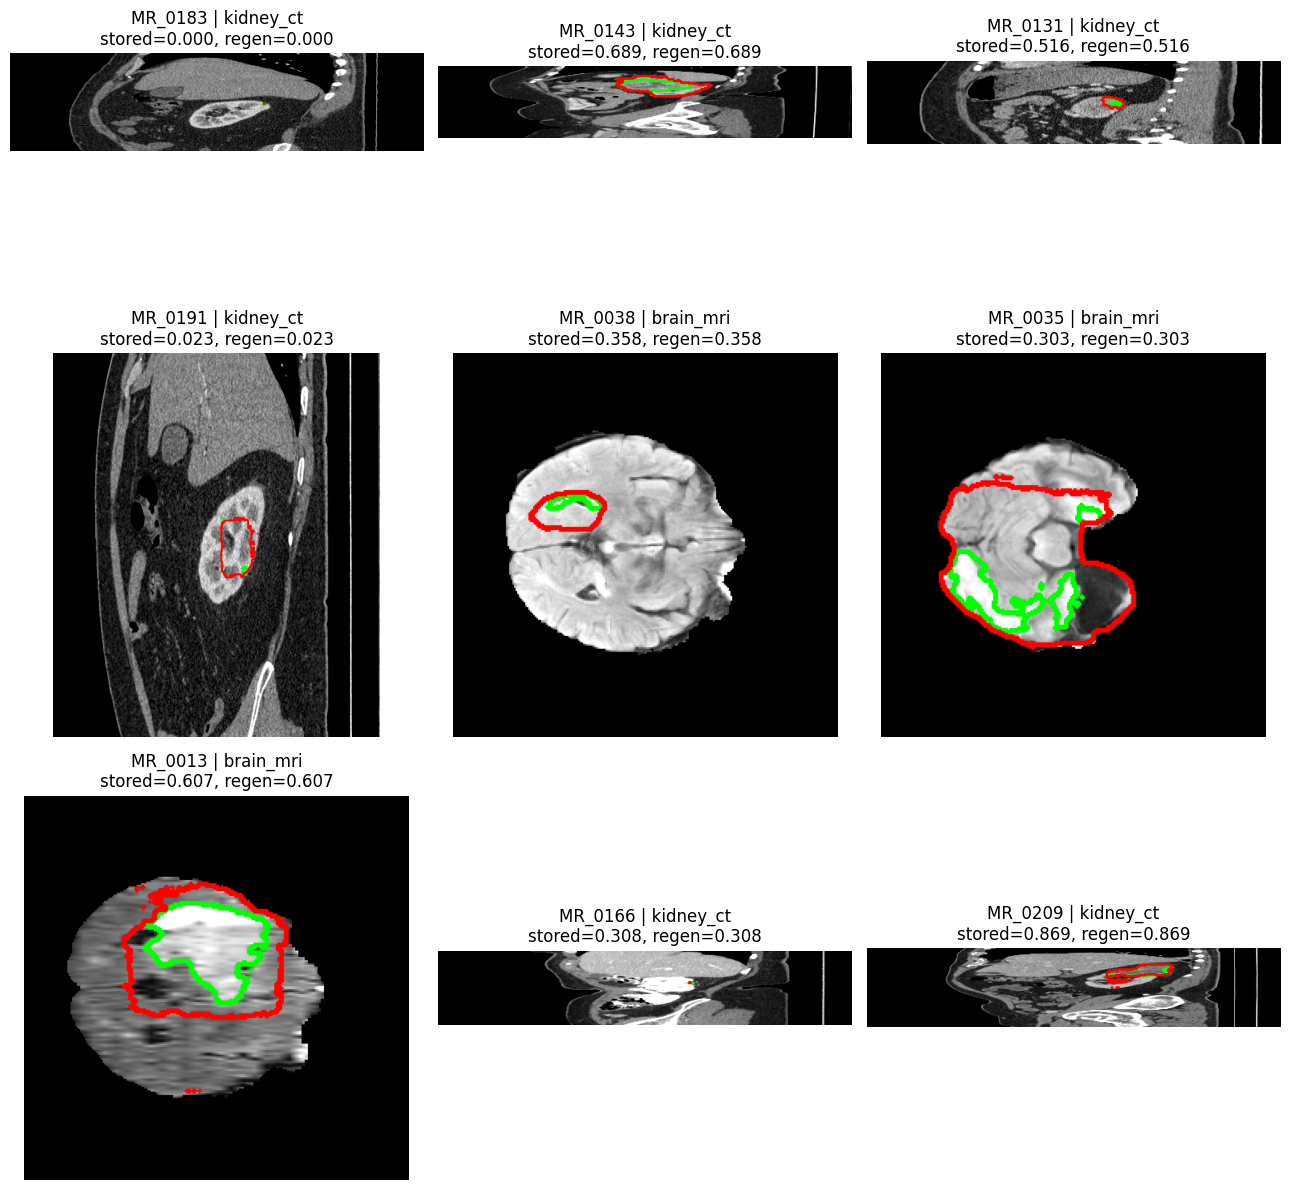

Saved QA figure: /content/drive/MyDrive/MedReasoner_SAM_2026/06_figures/01_asset_reproduction_QA_sample.png


In [16]:
# CELL 16 — Visual QA sample
# This cell displays INTERNAL audit panels. GT is shown here only for human verification.
if len(final_manifest):
    sample_n = min(9, len(final_manifest))
    sample = final_manifest.sample(sample_n, random_state=SEED)

    fig, axes = plt.subplots(3, 3, figsize=(13, 13))
    axes = np.array(axes).reshape(-1)

    for ax, (_, r) in zip(axes, sample.iterrows()):
        audit = cv2.cvtColor(
            cv2.imread(r["audit_overlay_internal_only"]),
            cv2.COLOR_BGR2RGB
        )
        ax.imshow(audit)
        ax.set_title(
            f"{r['benchmark_id']} | {r['domain']}\n"
            f"stored={r['stored_dice']:.3f}, regen={r['regen_dice']:.3f}"
        )
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    QA_FIG = PROJECT_ROOT / "06_figures" / "01_asset_reproduction_QA_sample.png"
    QA_FIG.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(QA_FIG, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved QA figure:", QA_FIG)

In [17]:
# CELL 17 — Final readiness gate for Notebook 02
expected = len(benchmark)
generated = len(final_manifest)

status_counts = (
    final_manifest["reproduction_status"].value_counts().to_dict()
    if len(final_manifest) else {}
)

fail_rows = (
    final_manifest[final_manifest["reproduction_status"] == "FAIL"].copy()
    if len(final_manifest) else pd.DataFrame()
)
warn_rows = (
    final_manifest[final_manifest["reproduction_status"] == "WARN"].copy()
    if len(final_manifest) else pd.DataFrame()
)

ready = (
    generated == expected
    and len(fail_rows) == 0
)

summary = {
    "pipeline_version": PIPELINE_VERSION,
    "expected_benchmark_cases": int(expected),
    "generated_asset_cases": int(generated),
    "missing_asset_cases": int(expected - generated),
    "reproduction_status_counts": {str(k): int(v) for k, v in status_counts.items()},
    "fail_count": int(len(fail_rows)),
    "warn_count": int(len(warn_rows)),
    "brain_generated": int(len(brain_asset_df)),
    "kidney_generated": int(len(kidney_asset_df)),
    "histopathology_generated": int(len(histo_asset_df)),
    "brain_source_note": (
        "Reproduced executed MSD Task01 channel-0/FLAIR pipeline. "
        "Manuscript modality label discrepancy must be resolved before submission."
    ),
    "final_manifest": str(FINAL_MANIFEST),
    "asset_root": str(ASSET_ROOT),
    "ready_for_notebook_02": bool(ready),
    "next_step": (
        "Notebook 02: blinded VLM segmentation-failure recognition experiment"
        if ready else
        "Resolve missing assets or Dice reproduction FAIL rows before VLM inference."
    )
}

STATUS_FILE = AUDIT_DIR / "01_asset_build_status.json"
STATUS_FILE.parent.mkdir(parents=True, exist_ok=True)
STATUS_FILE.write_text(json.dumps(summary, indent=2))

print("=" * 88)
print("NOTEBOOK 01 FINAL STATUS")
print("=" * 88)
print(json.dumps(summary, indent=2))

if len(warn_rows):
    print("\nWARN rows (inspect, but Notebook 02 may still proceed if scientifically justified):")
    display(
        warn_rows[[
            "benchmark_id", "domain", "record_id",
            "stored_dice", "regen_dice", "dice_abs_diff"
        ]].sort_values("dice_abs_diff", ascending=False)
    )

if len(fail_rows):
    print("\nFAIL rows — DO NOT proceed to VLM evaluation yet:")
    display(
        fail_rows[[
            "benchmark_id", "domain", "record_id",
            "stored_dice", "regen_dice", "dice_abs_diff"
        ]].sort_values("dice_abs_diff", ascending=False)
    )

print("\nSaved:", STATUS_FILE)

if ready:
    print("\n✅ READY FOR NOTEBOOK 02")
    print("Use ONLY image_path, sam_mask_path, and/or vlm_input_overlay_path as VLM inputs.")
    print("Do NOT expose gt_mask_internal_only or stored_dice to the VLM.")
else:
    print("\n⚠️ NOT READY FOR NOTEBOOK 02 YET")
    print("Send me this Cell 17 output; the next fix can be targeted.")

NOTEBOOK 01 FINAL STATUS
{
  "pipeline_version": "medreasoner-asset-build-01-v1",
  "expected_benchmark_cases": 220,
  "generated_asset_cases": 220,
  "missing_asset_cases": 0,
  "reproduction_status_counts": {
    "PASS": 220
  },
  "fail_count": 0,
  "warn_count": 0,
  "brain_generated": 94,
  "kidney_generated": 90,
  "histopathology_generated": 36,
  "brain_source_note": "Reproduced executed MSD Task01 channel-0/FLAIR pipeline. Manuscript modality label discrepancy must be resolved before submission.",
  "final_manifest": "/content/drive/MyDrive/MedReasoner_SAM_2026/01_manifests/medreasoner_vlm_asset_manifest.csv",
  "asset_root": "/content/drive/MyDrive/MedReasoner_SAM_2026/02_case_assets",
  "ready_for_notebook_02": true,
  "next_step": "Notebook 02: blinded VLM segmentation-failure recognition experiment"
}

Saved: /content/drive/MyDrive/MedReasoner_SAM_2026/00_setup_audit/01_asset_build_status.json

✅ READY FOR NOTEBOOK 02
Use ONLY image_path, sam_mask_path, and/or vlm_input_ov